<div class="alert alert-block alert-info"> 
    <center><h1 "> Tarea 2: Cálculo Científico I - MAT2605</h1> </center>
</div>
    <!-- <b></b>     -->
    <h4 style="color:#173F8A;;text-align:right;"> Profesor: Manuel A. Sánchez<br> Ayudantes: Diego Vera, Tomás Malfetano <br></h4>

<!-- 
<div class="alert alert-block alert-success"> Use green boxes sparingly, and only for some specific purpose that the other boxes can't cover. For example, if you have a lot of related content to link to, maybe you decide to use green boxes for related links from each section of a notebook. </div>

<div class="alert alert-block alert-warning"> Use yellow boxes for examples that are not inside code cells, or use for mathematical formulas if needed. </div>

<div class="alert alert-block alert-danger"> In general, just avoid the red boxes. </div>

############# Markdown parser in Sphinx ##################

<div class="admonition note"> <p class="admonition-title">Note</p> <p>You should note that the title will be automatically capitalized.</p> </div>

<div class="admonition danger"> <p class="admonition-title">Don't try this at home</p> <p>...</p> </div>
 -->
<!-- <div class="admonition important"> <p>This is an admonition box without a title.</p> </div> -->

<div class="alert alert-block alert-success"> <b> Nombre de estudiante: </b> Rafael Ignacio Lorca Muñoz</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-block alert-info"> <b> Problema 1. Descomposicion de Cholesky </b> </div>

a) Escriba un algoritmo (pseudoalgoritmo) para resolver el sistema lineal $Ax=b$, para $A\in \mathbb R^{n\times n}$ simétrica y definida positiva y $b\in \mathbb R^{n}$ usando la descomposición de Cholesky $A=L L ^\top$. Escriba el pseudoalgoritmo que calcula la descomposición.

b) Calcule el número de operaciones de floating point del algoritmo y compárelo con el número de operaciones de eliminación Gaussiana.

c) Programe los algoritmos anteriores y resuelva el sistema lineal $Ax = b$ con $A\in \mathbb R^{n\times n}, b\in \mathbb R^{n}$ dadas por:
$$
A = \begin{bmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \ddots & \vdots \\
0 & \ddots & \ddots & \ddots & 0\\
\vdots & \ddots & -1 & 2 & -1\\
0 & \cdots & 0 & -1 & 2
\end{bmatrix}, \qquad b = \frac{2}{(n+1)^2} \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \\ 1\end{bmatrix}
$$
Calcule para $n=3,4$ y proponga una fórmula para las entradas de $L$ en términos de $n$.

d) Para $n=99$ grafique el vector solución del sistema lineal $x$ versus el vector $t\in \mathbb R^{n}$, con $t_i = i/(n+1)$, $i=1,2,...,n$. Compare esta gráfica con la función $u(t) = t(1-t)$, $t\in(0,1)$. Comente acerca de estos resultados. 

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

a)
<div class="alert alert-block alert-code">

**Algoritmo:** Descomposición de Cholesky \
**Input:** $A \in \mathbb{R}^{n\times n}$\
**Output:** $L, L^T$ 

$L$ = Matrix $\in \mathbb{R}^{n\times n}$, $l_{ik}$ = Entradas de la matriz $L$.

$L = $ Matriz $0\in \mathbb{R}^{n\times n}$:

$\text{para } i = 1,2,\dots,n:\\$ 
$\quad \text{para } k = 1,2,\dots,n:\\$ 
$\quad \text{si } k < i:\\$ 
$\quad\quad l_{ik} = (a_{ik} - \sum\limits_{j=1}^{k-1}l_{ij}l_{kj}) / l_{kk}\\$ 
$\quad \text{si } k == i:\\$ 
$\quad\quad l_{ik} = \sqrt{a_{ii} - \sum\limits_{k=1}^{i-1}l_{ik}^2}\\$ 
$\quad \text{si } k > i:\\$ 
$\quad\quad l_{ik} = 0$ 

$L^T =$ Matriz $0\in \mathbb{R}^{n\times n}$, $l´= $ las entradas de $L^T$:

$\text{para } i = 1,2,\dots,n:\\$ 
$\quad \text{para } k = 1,2,\dots,n:\\$ 
$\quad\quad l´_{ki} = l_{ik}\\$ 

return $L$, $L^T$

<div>

Usamos la decomposición para resolver el sistema, para eso tomamos dos sistemas diferentes:
$$
    Ly = b
$$
$$
    L^Tx = y
$$

<div class="alert alert-block alert-code">

**Algoritmo:** Resolver sistema lineal usando Cholesky \
**Input:** $A \in \mathbb{R}^{n\times n} \ b \in \mathbb{R}^n\ , \ n\in \mathbb{N}$ \
**Output:** $x \in \mathbb{R}^n$ \

$L, L^T = $ Descomposición de Cholesky($A$)

$\text{para } i = 1,2,\dots,n:\\$ 
$\quad y_i = (b_i - \sum\limits_{j = 1}^{i-1}(L_{ij} * y_j) ) / L_{ii}\\$ 

$\text{para } i = n,n-1,\dots,1:\\$ 
$\quad x_i = (y_i - \sum\limits_{j = i+1}^{n}(L^T_{ij} * x_j) ) / L^T_{ii}\\$ 

$\ return\ x$

<div>

b) La descomposición de Cholesky, analizamos el ciclo interior:
- $k<i$:
  $\sum\limits_{j=1}^{k-1}l_{ij}l_{kj}\to k-1$ multiplicaciones + $k-2$ sumas. En total son $2k-3$ operaciones. $a_{ik} - \star$, acá es una resta y la división por $l_{kk} es una operación también. El total de esta operación es $2k-1$ operaciones. Finalmente se suman para todos los $k<i$: $\sum\limits^{i-1}_{k=1}(2k-1)$
- $k==1$:
  $\sum\limits^{i-1}_{k=1}l^2_{ik}\to i-1$ multiplicaciones + $i-2$ sumas, en total $2i-3$. La resta y la raiz cuadrada son 1 operación cada una, en total: $2i - 1$
- $k>i$:
  No hay operaciones.
Total: $\sum\limits^{i-1}_{k=1}(2k-1) + 2i-1$. 
[1] Buscando en internet, encontré que la suma de la descomposición de Cholesky tiene un coste conocido aproximado de $\frac{1}{3}n^3$.

El algoritmo para resolver con Cholesky el sistema lineal:
- Sustitución progresiva: $(b_i - \sum\limits_{j = 1}^{i-1}(L_{ij} * y_j) ) / L_{ii} \to i-1$ multiplicaciones + $i-2$ sumas, 1 resta y 1 división. Todo eso se repite n veces. Total: $\sum\limits^n_{i=1}(2i-1)$
- Sustitución regresiva: Es lo mismo que antes, aunque se hace  la suma al revés, igualmente se repiten los flops.
Total: $\sum\limits^{i-1}_{k=1}(2k-1) + 2i-1$

El total aproximado de este algoritmo es de $\frac{1}{3}n^3 + 2n^2$, comparando con la eliminación gaussiana, esta requiere de $\frac{2}{3}n^3$ [2]. Comparandola, se puede ver en el resultado y tambien de forma "intuitiva" que al solamente considerar la parte triangular inferior de la matriz, se necesita realizar la mitad de operaciones en el algoritmo de la descomposición de Cholesky.

[1] "Azevedo, R. (Nov, 2012). How to calculate the cost of Cholesky decomposition?. MathExchange. https://math.stackexchange.com/questions/217738/how-to-calculate-the-cost-of-cholesky-decomposition"

[2] "Astudentofmaths. (6 Dec, 2017). Why is efficency of Gaussian Elimination O(n^3)?. MathExchange https://math.stackexchange.com/questions/2554714/why-is-efficency-of-gaussian-elimination-on3"

In [2]:
# c) 

def descomposicion_Cholesky(A):
    n = np.size(A, 0)
    L = np.zeros((n, n))

    for i in range(n):
        for k in range(n):
            if k < i:
                elementos = 0
                for j in range(k):
                    elementos += L[i][j] * L[k][j]
                L[i][k] = (A[i][k] - elementos) / L[k][k]
            elif k == i:
                elementos = 0
                for j in range(i):
                    elementos += L[i][j] ** 2
                L[i][k] = np.sqrt(A[i][i] - elementos) 
            elif k > i:
                L[i][k] = 0
    
    L_T = L.T

    return L, L_T

def solve_sistem(L, L_T, b):
    # Usamos los algoritmos del profe

    n = L.shape[0]
    y = np.zeros(n)

    y[0] = b[0]/L[0,0]
    for i in range(1,n):
        y[i] = (b[i] - np.dot(L[i,0:i],y[0:i]))/L[i,i]
    
    x = np.zeros(n)
    x[n-1] = y[n-1]/L_T[n-1,n-1]
    for i in range(n-2,-1,-1):
        x[i] = (y[i] - np.dot(L_T[i,(i+1):n],(x[(i+1):n])))/L_T[i,i]
    
    return x

numeros = [3,4]

for n in numeros:
    A = np.zeros((n,n))
    for i in range(n):
        for k in range(n):
            if i == k:
                A[i][k] = 2
            elif k+1 == i or k-1 == i:
                A[i][k] = -1
            else:
                A[i][k] = 0
    
    L , L_T = descomposicion_Cholesky(A)

    b = (2/(n+1) * np.ones(n))

    x = solve_sistem(L , L_T, b)

    # Verificamos
    print(f"Iteración: {n}")
    print(f"Matriz A (size {n}x{n}):")
    print(A)
    print(f"\nL (triangular inferior):")
    print(L)
    print(f"\nL^T (transpuesta de L):")
    print(L_T)
    print(f"\nSolución:")
    print(x)

Iteración: 3
Matriz A (size 3x3):
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]

L (triangular inferior):
[[ 1.41421356  0.          0.        ]
 [-0.70710678  1.22474487  0.        ]
 [ 0.         -0.81649658  1.15470054]]

L^T (transpuesta de L):
[[ 1.41421356 -0.70710678  0.        ]
 [ 0.          1.22474487 -0.81649658]
 [ 0.          0.          1.15470054]]

Solución:
[0.75 1.   0.75]
Iteración: 4
Matriz A (size 4x4):
[[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]

L (triangular inferior):
[[ 1.41421356  0.          0.          0.        ]
 [-0.70710678  1.22474487  0.          0.        ]
 [ 0.         -0.81649658  1.15470054  0.        ]
 [ 0.          0.         -0.8660254   1.11803399]]

L^T (transpuesta de L):
[[ 1.41421356 -0.70710678  0.          0.        ]
 [ 0.          1.22474487 -0.81649658  0.        ]
 [ 0.          0.          1.15470054 -0.8660254 ]
 [ 0.          0.          0.          1.11803399]]

Solución:
[0.8 1.2 1.2 0.8]


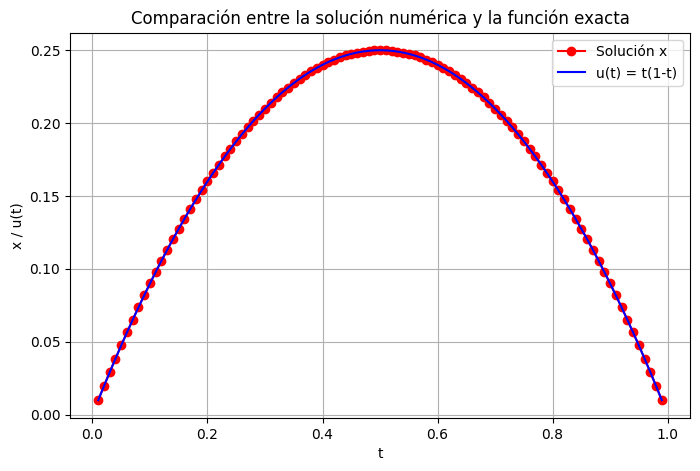

In [3]:
# d)
n = 99

A = np.zeros((n,n))
for i in range(n):
    for k in range(n):
        if i == k:
            A[i][k] = 2
        elif k+1 == i or k-1 == i:
            A[i][k] = -1
        else:
            A[i][k] = 0

b = 2/(n+1)**2 * np.ones(n)

L, L_T = descomposicion_Cholesky(A)
x = solve_sistem(L, L_T, b)


t = np.array([i/(n+1) for i in range(1,n+1)])
u = t*(1-t)

plt.figure(figsize=(8,5))
plt.plot(t, x, 'r-o', label='Solución x')
plt.plot(t, u, 'b-', label='u(t) = t(1-t)')
plt.xlabel('t')
plt.ylabel('x / u(t)')
plt.title('Comparación entre la solución numérica y la función exacta')
plt.legend()
plt.grid(True)
plt.show()

Podemos ver que la aproximación propuesta (línea azul) es igual o por lo menos se puede ver que la linea está superpuesta con la línea de la solución x.

<div class="alert alert-block alert-info"> <b> Problema 2. Numero de condicion </b> </div>

a) Sea $A\in \mathbb R^{n\times n}$. Demuestre que el numero de condicion en la norma 2 de $A$ es
$$
\text{cond}_2(A) = \frac{\sigma_1}{\sigma_n}
$$
donde $\sigma_1$ y $\sigma_n$ son el mayor y menor valor singular de $A$.

b) Calcule los numeros de condicion $\text{cond}_1$, $\text{cond}_2$,$\text{cond}_\infty$, para las siguientes matrices
$$
A_1 = \begin{bmatrix}
3 & 0 & 0 \\
0 & 5/2 & 3/4\\
0 & 3/4 & 5/4
\end{bmatrix},
\qquad
A_2 = \begin{bmatrix}
0.1 & 0 & 0 \\
10 & 0.1 & 0 \\
0 & 0 & 0.1
\end{bmatrix}
$$

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

a) Para $a\in \mathbb{R}^{n\times n}$ su descomposición en valores singulares es $A=U\Sigma V^{T}$, con $\Sigma =$ matriz diagonal con los valores singulares $\sigma_i$ en orden decreciente y las matrices U y V son matrices ortonormales, donde $u_j\in U$ son los vectores singulares izquierdos y los $v_j\in V^T$ los vectores singulares derechos. 

Como estos vectores son ortonormales, se puede escribir cualquier vector $x\in R^n$ como combinación lineal de estos vectores, luego para el sistema:
$$
Ax=b
$$
$$
A(x+\triangle x) = b+\triangle b
$$
se puede expresar lo siguiente:
$$
x = \alpha_1 v_1+\alpha_2 v2+\dots+\alpha_n v_n = \sum\limits^n_{j=1} \alpha_j v_j \ , \ \triangle x = \beta_1 v_1+\beta_2 v2+\dots+\beta_n v_n = \sum\limits^n_{j=1} \beta_j v_j
$$
$$
b = Ax = A(\sum\limits^n_{j=1} \alpha_j v_j) = \sum\limits^n_{j=1} \alpha_j A v_j = \sum\limits^n_{j=1} \alpha_j \sigma_j u_j \ , \ \triangle b = A\triangle x = A(\sum\limits^n_{j=1} \beta_j v_j) = \sum\limits^n_{j=1} \beta_j A v_j = \sum\limits^n_{j=1} \beta_j \sigma_j u_j
$$

Como $u_j, v_j$ son ortonormales: $||u_j||_2 = ||v_j||_2 = 1$;
$$
||x||_2^2 = \sum\limits^n_{j=1} \alpha_j^2 \ , \ ||\triangle x||_2^2 = \sum\limits^n_{j=1} \beta_j^2 \ , \ ||b||_2^2 = \sum\limits^n_{j=1} \alpha_j^2 \sigma_j^2 \ , \ ||\triangle b ||_2^2 = \sum\limits^n_{j=1} \beta_j^2 \sigma_j^2
$$

Queremos acotar $\frac{||\triangle x||_2^2}{||x||_2^2}$ con $\frac{||\triangle b ||_2^2}{|| b ||_2^2}$. De $||b||_2^2= \sum\limits^n_{j=1} \alpha_j^2 \sigma_j^2$:
$$
\min_j \sigma^2_j \sum\limits^n_{j=1} \alpha_j^2 \leq \sum\limits^n_{j=1} \alpha_j^2 \sigma_j^2 \leq \max_j \sigma^2_j \sum\limits^n_{j=1} \alpha_j^2
$$
Luego: $||\triangle x ||^2_2 \leq \frac{||\triangle b ||^2_2}{\sigma_n^2}$, con $\sigma_n :=$ el menor valor singular de A. El desarrollo para acotar $||x||_2^2$ es análogo, combinando ambas se llega a:
$$
\frac{||\triangle x||_2^2}{||x||_2^2} \leq \frac{\sigma_1^2}{\sigma_n^2} \cdot \frac{||\triangle b||_2^2}{||b||_2^2}
$$
Tomando la raiz cuadrada y la definición se obtiene:
$$
\kappa_2(A) = \max_{\triangle b \neq 0}(\frac{||\triangle x||_2 /||x||_2}{||\triangle b||_2 /||b||_2}) = \frac{\sigma_1}{\sigma_n}
$$

b) Primero, recordemos: $cond_a(A)= ||A||_a ||A^{-1}||_a$. Calculamos:
$$
A_1^{-1} = \begin{bmatrix}
1/3 & 0 & 0 \\
0 & 20/41 & -12/41\\
0 & -12/41 & 40/41
\end{bmatrix},
\qquad
A_2^{-1} = \begin{bmatrix}
10 & 0 & 0 \\
-1000 & 10 & 0 \\
0 & 0 & 10
\end{bmatrix}
$$

**1.i)** $cond_1(A_1): \max\{\sum\limits_{i=1}^n |a_{ij}|,1\leq j\leq n \} \max\{\sum\limits_{i=1}^n |a'_{ij}|,1\leq j\leq n \}$ = $\max\{3,13/4,2\} \max \{1/3,8/41,28/41\}= \frac{13}{4}\cdot\frac{28}{41}:$
$$ cond_1(A_1) = 2.2195 $$

**1.ii)** $cond_2(A_1): \sqrt{\rho(A^TA)} \sqrt{\rho(A^{-1^T}A^{-1})}$ donde $\rho(A^TA)$ es el radio espectral de la matriz $A^TA$ (máximo valor propio de la matriz $A^TA$). Se hace en un código en python a continuación y se calcula:  
$$ cond_2(A_1) = 3.3381 $$

**1.iii)** $cond_\infty(A_1): \max\{\sum\limits_{j=1}^n |a_{ij}|,1\leq i\leq n \} \max\{\sum\limits_{j=1}^n |a'_{ij}|,1\leq i\leq n \}$ = $\max\{3,13/4,2\} \max \{1/3,8/41,28/41\}= \frac{13}{4}\cdot\frac{28}{41}:$
$$ cond_\infty(A_1) = 2.2195 $$

Para la matriz $A_2$ el cálculo es análogo:

**2.i)** $cond_1(A_2): \max\{\sum\limits_{i=1}^n |a_{ij}|,1\leq j\leq n \} \max\{\sum\limits_{i=1}^n |a'_{ij}|,1\leq j\leq n \}$ = $\max\{10.1,0.1,0.1\} \max \{1010,10,10\}= 10.1\cdot 1010:$
$$ cond_1(A_2) = 10201 $$

**2.ii)** $cond_2(A_2): \sqrt{\rho(A^TA)} \sqrt{\rho(A^{-1^T}A^{-1})}$ donde $\rho(A^TA)$ es el radio espectral de la matriz $A^TA$ (máximo valor propio de la matriz $A^TA$). Se hace en un código en python a continuación y se calcula:  
$$ cond_2(A_2) = 10001.9999 $$

**2.iii)** $cond_\infty(A_2): \max\{\sum\limits_{j=1}^n |a_{ij}|,1\leq i\leq n \} \max\{\sum\limits_{j=1}^n |a'_{ij}|,1\leq i\leq n \}$ = $\max\{0.1,10.1,0.1\} \max \{10,1010,10\}= 10.1\cdot 1010:$
$$ cond_\infty(A_2) = 10201 $$

In [4]:
# Las inversas las hice a mano, pero luego me dió lata seguir a si que acá va el codigo:
import numpy as np

def calculate_cond2(matrizA: np.matrix):
    # Calcular la inversa
    inv_matrizA = np.linalg.inv(matrizA)
    # Calcular la transpuesta
    trs_matrizA = matrizA.T
    trs_matrizAinv = inv_matrizA.T

    # Calcular radio espectral
    rho_A = trs_matrizA @ matrizA
    rho_Ainv = trs_matrizAinv @ inv_matrizA
    # Máximo de los valores propios y raiz
    eig_ATA, eig_ATAinv = np.linalg.eigvals(rho_A), np.linalg.eigvals(rho_Ainv)
    radioA, radioAinv = max(eig_ATA), max(eig_ATAinv)
    radio_espectralA, radio_espectralAinv = np.sqrt(radioA), np.sqrt(radioAinv)

    # Resultado
    cond_2A = radio_espectralA * radio_espectralAinv

    return cond_2A

matrizA1 = np.array([[3,0,0],
                     [0,5/2,3/4],
                     [0,3/4,5/4]])

matrizA2 = np.array([[0.1,0,0],
                     [10,0.1,0],
                     [0,0,0.1]])

inv_matrizA1 = np.linalg.inv(matrizA1)
inv_matrizA2 = np.linalg.inv(matrizA2)

print(inv_matrizA1) 
print('\n',inv_matrizA2)

cond2_A1 = calculate_cond2(matrizA1)
cond2_A2 = calculate_cond2(matrizA2)

print('\n Número de condición de matriz 1:',cond2_A1)
print('\n Número de condición de matriz 2:',cond2_A2)


[[ 0.33333333  0.          0.        ]
 [ 0.          0.48780488 -0.29268293]
 [ 0.         -0.29268293  0.97560976]]

 [[   10.     0.     0.]
 [-1000.    10.    -0.]
 [    0.     0.    10.]]

 Número de condición de matriz 1: 3.338085318425364

 Número de condición de matriz 2: 10001.999900019991


Hay diferencias enormes entre los números de condición de la matriz $A_1$ con la matriz $A_2$, esto quiere decir que el problema relacionado a la matriz 2 está **mal condicionado** ya que todos los números de condición de la matriz 2 en las tres normas son muy grandes (comparados con $A_1$), esto también muestra la equivalencia de las normas en $\mathbb{R}^n$ ya que para una matriz mal condicionada, el numero de condición es alto para todas las normas en dicho espacio.

<div class="alert alert-block alert-info"> <b> Problema 3. Sistema perturbado </b> </div>

Sea 
$$
A =\begin{bmatrix}
1000 & 10 & 1 \\ 
-1000 & 0 & 0 \\
1000 & 0 & 1
\end{bmatrix}
$$
y sea $b\in \mathbb R^{3}$ con $1\leq b_i \leq 10$. Sean $\Delta A \in \mathbb R^{3 \times 3}$ y $\Delta b \in \mathbb R^{3}$ las perturbaciones de $A$ y $b$.

a) Considerando el sistema perturbado para $b$, es decir $A(x+\Delta x) = b +\Delta b$, estime 
$$
e_{b} = \frac{\|\Delta b\|_{\infty}}{\|b\|_{\infty}}
$$
de tal forma que 
$$
\frac{\|\Delta x \|_{\infty}}{\| x \|_{\infty}} < 10^{-2}. \qquad (\star)
$$
b) Ahora consideremos el sistema perturbado $ (A+\Delta A) (x+\Delta x) = b$, estime
$$
e_{A} = \frac{\|\Delta A\|_{\infty}}{\|A\|_{\infty}}
$$
de tal forma que se satisface $(\star)$.

c) Derive un estimado para la perturbación relativa de $x$ para el sistema con perturbación en $A$ y $b$, es decir, $(A+\Delta A)(x+\Delta x) = b+\Delta b$. Estime nuevamente los números $e_{A}$ y $e_{b}$ tal que se satisfaga $(\star)$.


<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

a)
De las clases sabemos que cuando se tiene $A\in \mathbb{R}^{n\times n}$ invertible, el sistema Ax = b y el sistema perturbado por $\Delta b$: $A(x+\Delta x) = b + \Delta b$. Entonces,
$$ \frac{||\Delta x||}{||x||} \leq Cond(A)\frac{||\Delta b||}{||b||} $$

Calculamos primero el número de condición $\infty$ de la matriz A:

In [5]:
A = np.array([[1000, 10, 1],
              [-1000, 0, 0],
              [1000, 0, 1]])
print(np.invert(A))
print(np.linalg.det(A) != 0)
(10)**(-2) / (1011*1014)

[[-1001   -11    -2]
 [  999    -1    -1]
 [-1001    -1    -2]]
True


9.754631986999027e-09

$$ Cond_\infty(A) = 1025154 $$

Luego, queremos que se cumpla $\star$, para eso necesitamos que $Cond_\infty(A)\frac{||\Delta b||}{||b||} < 10^{-2}$. Luego, 

$$e_b = \frac{||\Delta b||}{||b||} < 9.755\cdot 10^{-9} $$

b) Al igual que el caso anterior, sabemos que se cumple para el sistema perturbado $(A+\Delta A)(x+ \Delta  x) = b$:
$$ \frac{||\Delta x||}{||x+\Delta x||} \leq Cond(A) \frac{||\Delta A||}{||A||}$$

Queremos que se cumpla $\star$, entonces aproximando el lado izquierdo de la desigualdad  (igualmente se puede hacer sin problema para $x >>> \Delta x$):


$$  Cond(A) e_A < 10^{-2} , e_A < \frac{10^{-2}}{Cond_\infty(A)} $$
$$ e_A < 9.755\cdot 10^{-9} $$


c) Partimos desarrollando el sistema perturbado:
$$
(A+\Delta A)(x+\Delta x) = b+\Delta b \ , \ Ax+A\Delta x + \Delta A x +\Delta A\Delta x = b+\Delta b
$$
Reemplazamos $Ax = b$:
$$
b +A\Delta x + \Delta A x +\Delta A\Delta x = b + \Delta b \ , \ A\Delta x + \Delta A x +\Delta A\Delta x = \Delta b
$$
Despreciando la multiplicación de las perturbaciones, obtenemos:
$$
A\Delta x + \Delta A x  = \Delta b
$$
Tomamos la normas (en este caso infinito) a ambos lados:
$$
||A\Delta x + \Delta A x||_\infty  = ||\Delta b||_\infty \ (,\text{desig }\triangle \to) \ ||A\Delta x ||_\infty + ||\Delta A x||_\infty  \leq ||\Delta b||_\infty
$$
$$
||A||||\Delta x ||_\infty + ||\Delta A|||| x||_\infty  \leq ||\Delta b||_\infty \ , \ ||\Delta x ||  \leq \frac{||\Delta b||}{||A||} -  \frac{||\Delta A||}{||A||}|| x|| 
$$
Dividiendo por la norma de x y sabiendo que Ax = b, se obtiene finalmente:
$$
\frac{||\Delta x ||}{||x||}  \leq \frac{||\Delta b||}{||b||} -  \frac{||\Delta A||}{||A||}
$$

Para que se satisfaga entonces $\star$:
$$
e_b - e_A < 10^{-2}
$$

<div class="alert alert-block alert-info"> <b> Problema 4. Factorizacion matrices simetricas </b> </div>

a) Sea $A\in \mathbb R^{n\times n}$. Muestre que si $A$ es simetrica entonces tiene una factorizacion $A = LD L^\top$, donde $L$ es una matriz triangular inferior con elementos en la diagonal igual a 1, y $D$ es una matriz diagonal.

b) Similar a lo que se desarrollo para la factorizacion de Cholesky, encuentre un pseudoalgoritmo para calcular la factorizacion $A = L D L^\top$.

c) Muestre que si $A$ es definida positiva entonces los elementos de $D$ son positivos.

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

a)
Sea $A$ simétrica, esto significa $A=A^T$. Construimos $L,D$. Mantenemos la diagonal $D_{ii}$ y armamos D, luego eliminamos los elementos debajo de la diagonal. Guardamos los multiplicadores en la matriz L, como A es simétrica, los elementos de abajo de la diagonal son iguales a los de arriba de ella, por lo que los multiplicadores guardados en L, también sirven para eliminar los elementos de arriba, por eso $A = LDL^T$.

b)
<div class="alert alert-block alert-code">

**Algoritmo:** Factorización $LDL^\top$
**Input:** $A \in \mathbb{R}^{n\times n}$ simétrica
**Output:** $L \in \mathbb{R}^{n\times n}$ triangular inferior con 1s en la diagonal, $D \in \mathbb{R}^{n\times n}$ diagonal\

$L = $ Matriz identidad $\in \mathbb{R}^{n\times n}$, $D = $ Matriz cero $\in \mathbb{R}^{n\times n}$

$\text{para } i = 1,2,\dots,n:\\$
$\quad D_{ii} = a_{ii} - \sum\limits_{k=1}^{i-1} L_{ik}^2 D_{kk}\\$
$\quad \text{para } j = i+1,\dots,n:\\$
$\quad\quad L_{ji} = \frac{1}{D_{ii}} \left(a_{ji} - \sum\limits_{k=1}^{i-1} L_{jk} L_{ik} D_{kk} \right)\\$

$\ return\ L, D$

</div>

c)
Una matriz es definida positiva si es simétrica y el producto de la transpuesta de un vector no nulo por ella y el vector es positivo $ (x^TAx)>0 $. 

$$ x^TAx = x^T(LDL^T)x = x^TLDL^Tx = (L^Tx)^TD(L^Tx) $$
Luego definiendo el vector $y=L^Tx$, entonces:
$$ y^TDy $$
Como A es definida positiva, D también lo tiene que ser, luego como es una matriz diagonal, todos los elementos diagonales de la matriz D deben ser positivos (sino el determinante de alguna submatriz sería negativo, lo que contradice que sea definida positiva).